In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_path = '../data/raw/TMJA2016_2019_Propre.csv'
df = pd.read_csv(file_path)

print(df.columns)
print(df.head(3))
df.shape

Index(['objetID', 'route', 'longueur', 'depPrD', 'xD', 'yD', 'zD', 'depPrF',
       'xF', 'yF', 'zF', 'anneeMesureTrafic', 'TMJA', 'geopoint_depart',
       'geopoint_fin', 'TMJA_avg', 'TMJA_actualise', 'count'],
      dtype='object')
   objetID  route  longueur  depPrD         xD          yD  zD  depPrF  \
0  TMJ19_1  A0001    2440.0      93  653006.60  6867037.55   0      93   
1  TMJ19_2  A0001     785.2      93  652895.68  6869486.50   0      93   
2  TMJ19_3  A0001     401.8      93  653192.95  6870100.70   0      93   

          xF          yF   zF  anneeMesureTrafic      TMJA  \
0  652895.68  6869486.50  0.0               2019  132186.0   
1  653192.95  6870100.70  0.0               2019  132186.0   
2  653570.77  6870241.67  0.0               2019  132186.0   

             geopoint_depart               geopoint_fin      TMJA_avg  \
0  POINT(2.358973 48.901624)  POINT(2.357188 48.923638)  94409.742857   
1  POINT(2.357188 48.923638)  POINT(2.361177 48.929182)  94409.742857   


(18315, 18)

In [2]:
file_path = '../data/raw/BornesPropres.csv'
bn = pd.read_csv(file_path)

/tmp/ipykernel_2374/2723296349.py:2: DtypeWarning: Columns (15,16,17,18,19,20,21,26,30) have mixed types. Specify dtype option on import or set low_memory=False.
  bn = pd.read_csv(file_path)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   objetID            4428 non-null   object 
 1   route              18315 non-null  object 
 2   longueur           18315 non-null  float64
 3   depPrD             18315 non-null  int64  
 4   xD                 18315 non-null  float64
 5   yD                 18315 non-null  float64
 6   zD                 18315 non-null  int64  
 7   depPrF             18315 non-null  int64  
 8   xF                 18315 non-null  float64
 9   yF                 18315 non-null  float64
 10  zF                 18315 non-null  float64
 11  anneeMesureTrafic  18315 non-null  int64  
 12  TMJA               17628 non-null  float64
 13  geopoint_depart    18315 non-null  object 
 14  geopoint_fin       18315 non-null  object 
 15  TMJA_avg           18315 non-null  float64
 16  TMJA_actualise     183

In [4]:
bn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163930 entries, 0 to 163929
Data columns (total 46 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   nom_amenageur                        163930 non-null  object 
 1   contact_amenageur                    163930 non-null  object 
 2   nom_operateur                        163930 non-null  object 
 3   contact_operateur                    163930 non-null  object 
 4   nom_enseigne                         163930 non-null  object 
 5   id_station_itinerance                163930 non-null  object 
 6   id_station_local                     110799 non-null  object 
 7   nom_station                          163930 non-null  object 
 8   implantation_station                 163930 non-null  object 
 9   adresse_station                      163928 non-null  object 
 10  coordonneesXY                        163930 non-null  object 
 11  nbre_pdc     

In [5]:
bn.describe()

,nbre_pdc,puissance_nominale,consolidated_longitude,consolidated_latitude
count,163930.000000,163930.000000,163930.000000,163930.000000
mean,10.825438,72.256529,2.806926,46.716114
std,41.296689,95.819985,4.626517,4.243213
min,0.000000,0.000000,-149.905377,-22.196200
25%,2.000000,22.000000,1.127372,44.906531
50%,4.000000,22.000000,2.510871,47.343958
75%,8.000000,100.000000,4.857592,48.849951
max,505.000000,1601.600000,166.445400,61.520355


In [6]:
# Lire le fichier des départements
import geopandas as gpd
from shapely.wkt import loads as wkt_loads
departements_read = gpd.read_file("../data/raw/departements.geojson")  # chemin du département


In [7]:
#Fonction pour convertir les point Geo en département
def departements(geo) :
    
    point = wkt_loads(geo)
    matching_dept = departements_read[departements_read.geometry.contains(point)]
    return matching_dept
bn["departement"]= bn["Geopoint"].apply(func=departements) #applique la fonction au dataset borne en créant une nouvelle colonne


In [8]:
bn["departement"][0]


,code,nom,geometry
67,67,Bas-Rhin,"POLYGON ((7.63529 49.05416, 7.67449 49.04504, ..."


In [9]:
# Création du fichier en clean
# output_file_path = '../data/clean/BornesPropres_with_depart.csv'
# bn.to_csv(output_file_path, index=False)
# print(f"\nFichier sauvegardé : {output_file_path}")

In [9]:
bn["Geopoint"]

0           POINT(7.762694 48.825613)
1           POINT(7.762694 48.825613)
2           POINT(7.762694 48.825613)
3           POINT(7.762694 48.825613)
4            POINT(7.761841 48.82704)
                     ...             
163925              POINT(2.21 48.91)
163926              POINT(4.97 45.73)
163927    POINT(3.1446482 45.7582871)
163928      POINT(2.138365 49.045084)
163929      POINT(2.192848 51.005589)
Name: Geopoint, Length: 163930, dtype: object

In [10]:
df.describe()

,longueur,depPrD,xD,yD,zD,depPrF,xF,yF,zF,anneeMesureTrafic,TMJA,TMJA_avg,TMJA_actualise,count
count,18315.000000,18315.000000,1.831500e+04,1.831500e+04,18315.0,18315.000000,1.831500e+04,1.831500e+04,18315.0,18315.000000,17628.000000,18315.000000,18315.000000,18315.000000
mean,3725.409064,47.475621,6.934011e+05,6.633787e+06,0.0,47.360470,6.936308e+05,6.633248e+06,0.0,2017.446137,30331.800431,30452.931823,31676.307287,179.150259
std,5356.571686,27.052540,1.992214e+05,2.399941e+05,0.0,27.023455,1.999998e+05,2.406245e+05,0.0,1.135170,32978.404025,25650.684794,32406.030518,252.881329
min,0.100000,1.000000,1.504183e+05,6.148789e+06,0.0,1.000000,1.499013e+05,6.148789e+06,0.0,2016.000000,0.000000,1281.000000,272.000000,1.000000
25%,348.450000,26.000000,5.666412e+05,6.426178e+06,0.0,26.000000,5.664759e+05,6.426120e+06,0.0,2016.000000,9925.000000,12324.956268,11075.000000,41.000000
50%,1428.000000,47.000000,6.940317e+05,6.667581e+06,0.0,47.000000,6.968963e+05,6.665154e+06,0.0,2017.000000,17612.000000,18475.732143,18834.000000,95.000000
75%,4890.000000,70.000000,8.452396e+05,6.847381e+06,0.0,69.000000,8.455341e+05,6.846915e+06,0.0,2018.000000,39776.000000,46205.600000,42370.000000,196.000000
max,64979.000000,95.000000,1.076648e+06,7.103047e+06,0.0,95.000000,1.074272e+06,7.106915e+06,0.0,2019.000000,238387.000000,153125.196078,238387.000000,1092.000000


In [11]:
df["anneeMesureTrafic"]

0        2019
1        2019
2        2019
3        2019
4        2019
         ... 
18310    2016
18311    2016
18312    2016
18313    2016
18314    2016
Name: anneeMesureTrafic, Length: 18315, dtype: int64

Text(0, 0.5, 'TMJA ')

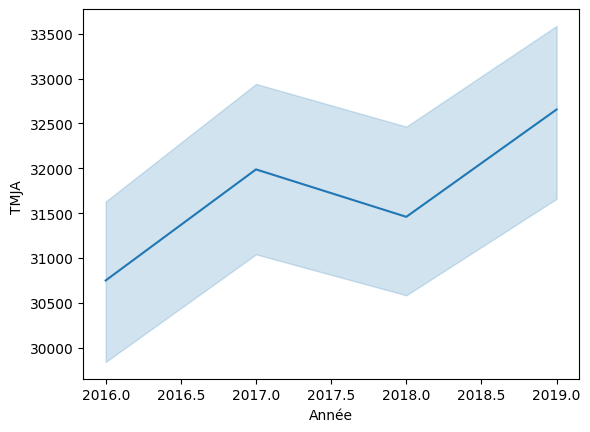

In [12]:
sns.lineplot(data=df,y= df["TMJA_actualise"],x= df["anneeMesureTrafic"])
plt.xlabel("Année")
plt.ylabel("TMJA ")

In [13]:
avg =df["TMJA_actualise"].groupby(by=df.route).mean()
avg = avg.to_frame() #modifie le type en dataframe
top_10=avg.sort_values("TMJA_actualise",ascending= False).head(10)
top_10.index



Index(['A0015', 'A0003', 'A0086', 'A0012', 'N0230', 'A0620', 'A0630', 'A0624',
       'A0621', 'N0201'],
      dtype='object', name='route')

Text(0, 0.5, 'TMJA moyen')

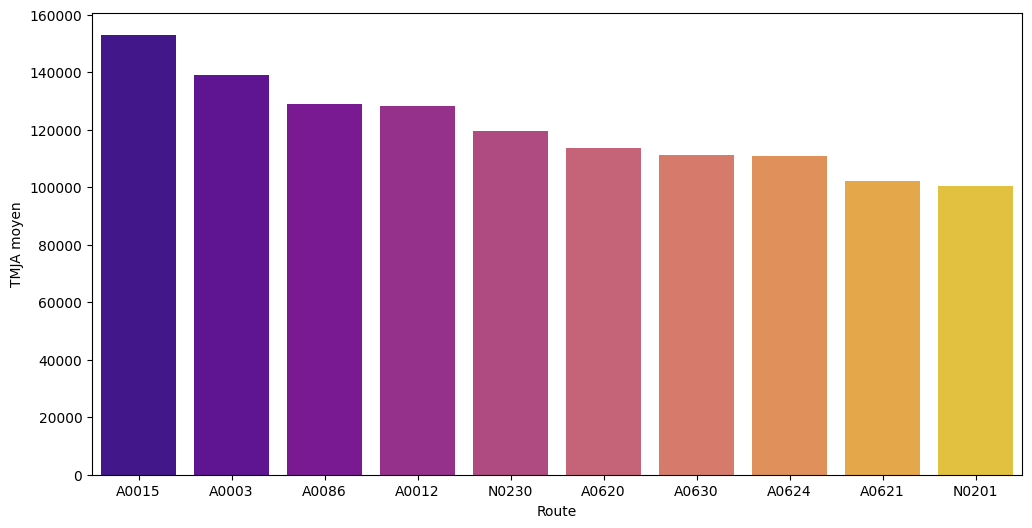

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_10,y=top_10["TMJA_actualise"],x=top_10.index,palette="plasma")
plt.xlabel("Route")
plt.ylabel("TMJA moyen")

In [15]:
correlation = np.corrcoef([df['longueur'],df['TMJA_actualise'],df['anneeMesureTrafic'],df["depPrD"]])
correlation

array([[ 1.        , -0.07226158,  0.03053843, -0.01752214],
       [-0.07226158,  1.        ,  0.01847677,  0.2254963 ],
       [ 0.03053843,  0.01847677,  1.        , -0.00595705],
       [-0.01752214,  0.2254963 , -0.00595705,  1.        ]])

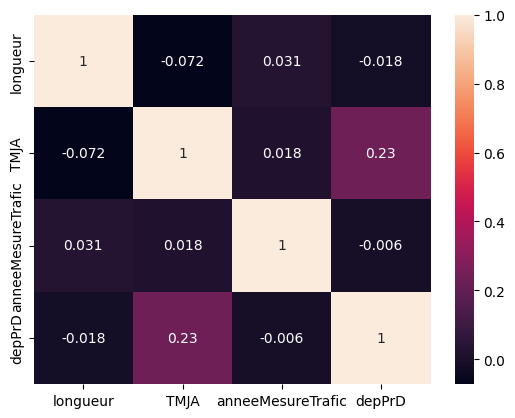

In [16]:
heatmap = sns.heatmap(data =correlation,annot=True,xticklabels=["longueur","TMJA","anneeMesureTrafic","depPrD"],yticklabels=["longueur","TMJA","anneeMesureTrafic","depPrD"])

/tmp/ipykernel_2374/2590797253.py:7: DtypeWarning: Columns (15,16,17,18,19,20,21,26,30) have mixed types. Specify dtype option on import or set low_memory=False.
  bornes = pd.read_csv("../data/raw/BornesPropres.csv", delimiter=",", encoding='utf-8')


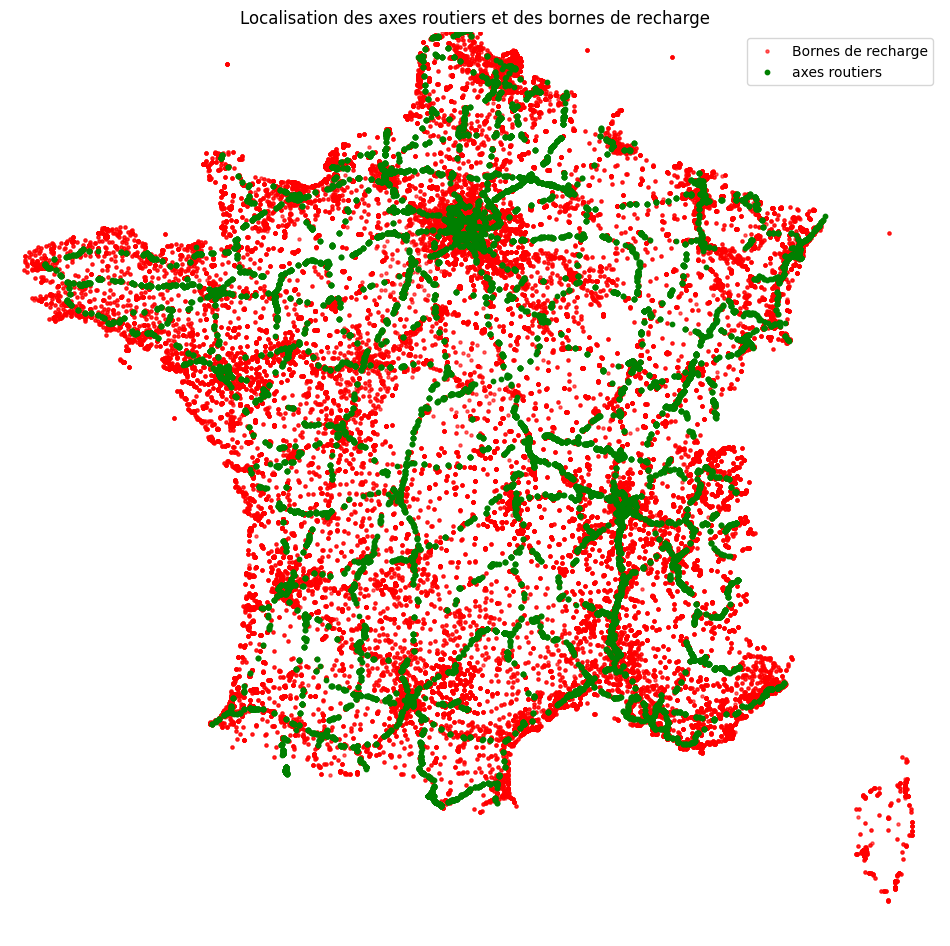

In [17]:
from shapely import wkt

# Convertir les colonnes de géopoint en géométrie
df['geopoint_depart'] = df['geopoint_depart'].apply(wkt.loads) #A executer UNE FOIS 
gdf = gpd.GeoDataFrame(df, geometry='geopoint_depart', crs="EPSG:4326")
# Charger bornes
bornes = pd.read_csv("../data/raw/BornesPropres.csv", delimiter=",", encoding='utf-8')
bornes = bornes[(bornes['consolidated_latitude'].notnull()) & (bornes['consolidated_longitude'].notnull())]
gdf_bornes = gpd.GeoDataFrame(
    bornes, geometry=gpd.points_from_xy(bornes.consolidated_longitude, bornes.consolidated_latitude), crs="EPSG:4326"
)
fig, ax = plt.subplots(figsize=(12,12))
# Affichage Bornes en rouge
gdf_bornes.plot(ax=ax, color='red', markersize=5, alpha=0.6, label='Bornes de recharge')
# Affichage trafic routier
gdf.plot(ax=ax, markersize=10,color='green', label='axes routiers')
plt.legend()
plt.title("Localisation des axes routiers et des bornes de recharge")
ax.set_xlim(-5, 10)
ax.set_ylim(41, 51)
ax.set_axis_off()
plt.show()


In [18]:
# compter le nombre de borne
bornes_count = bn.groupby('Geopoint').size()
bornes_count = bornes_count.to_frame()
bornes_count

,0
Geopoint,
POINT(-0.000976 49.324569),2
POINT(-0.000992 45.015003),4
POINT(-0.001139 44.91209),4
POINT(-0.001493 44.981499),2
POINT(-0.001617 47.077716),8
...,...
POINT(9.54776 42.26466),2
POINT(9.550176 42.114619),5
POINT(9.550573 42.214694),6


In [19]:
# compter le nombre de trançons
print(type(df['geopoint_depart']))
print(type(bn['Geopoint']))
axe_count = df.groupby('geopoint_fin').size()
axe_count =axe_count.to_frame()
axe_count



<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>


,0
geopoint_fin,
POINT(-0.006387 43.963454),2
POINT(-0.012328 43.162904),2
POINT(-0.015681 46.452786),4
POINT(-0.015996 44.496639),4
POINT(-0.019679 43.156990),2
...,...
POINT(8.081817 48.892922),1
POINT(8.085577 48.896751),1
POINT(8.086843 48.897879),1


In [20]:
test =bn["departement"].values
test
# test2 = bn.loc[180,"departement"]
# test2

array([   code       nom                                           geometry
       67   67  Bas-Rhin  POLYGON ((7.63529 49.05416, 7.67449 49.04504, ...,
          code       nom                                           geometry
       67   67  Bas-Rhin  POLYGON ((7.63529 49.05416, 7.67449 49.04504, ...,
          code       nom                                           geometry
       67   67  Bas-Rhin  POLYGON ((7.63529 49.05416, 7.67449 49.04504, ...,
       ...,
          code          nom                                           geometry
       63   63  Puy-de-Dôme  POLYGON ((2.56538 46.14303, 2.64069 46.11848, ...,
          code         nom                                           geometry
       95   95  Val-d'Oise  POLYGON ((2.59052 49.07965, 2.57203 49.06149, ...,
          code   nom                                           geometry
       59   59  Nord  MULTIPOLYGON (((3.04040 50.15971, 3.06301 50.1...],
      dtype=object)

In [27]:
bn["departement"]

0            code       nom                             ...
1            code       nom                             ...
2            code       nom                             ...
3            code       nom                             ...
4            code       nom                             ...
                                ...                        
163925       code             nom                       ...
163926       code    nom                                ...
163927       code          nom                          ...
163928       code         nom                           ...
163929       code   nom                                 ...
Name: departement, Length: 163930, dtype: object

In [22]:
split =list(str(test))
print(split)
concat = ''.join(split)


['[', ' ', ' ', ' ', 'c', 'o', 'd', 'e', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'n', 'o', 'm', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'g', 'e', 'o', 'm', 'e', 't', 'r', 'y', '\n', ' ', '6', '7', ' ', ' ', ' ', '6', '7', ' ', ' ', 'B', 'a', 's', '-', 'R', 'h', 'i', 'n', ' ', ' ', 'P', 'O', 'L', 'Y', 'G', 'O', 'N', ' ', '(', '(', '7', '.', '6', '3', '5', '2', '9', ' ', '4', '9', '.', '0', '5', '4', '1', '6', ',', ' ', '7', '.', '6', '7', '4', '4', '9', ' ', '4', '9', '.', '0', '4', '5', '0', '4', ',', ' ', '.', '.', '.', '\n', ' ', ' ', ' ', ' ', 'c', 'o', 'd', 'e', ' ', ' ', ' ', ' ', ' ', ' ', ' ', 'n', 'o', 'm', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' 

In [23]:
chiffres = [elem for elem in split if elem.isdigit()]
resultat = ''.join(chiffres)
resultat = resultat[2:4]
resultat

'67'

In [25]:
# Fonction pour extraire le numéro de département:

def num_departements(d) :
    e=list(str(d))
    chiffres = [elem for elem in e if elem.isdigit()]
    resultat = ''.join(chiffres)
    numero = resultat[2:4]
    return numero
bn["num_departement"]= bn["departement"].apply(func=num_departements) #applique la fonction au dataset borne en créant une nouvelle colonne



In [26]:
bn["num_departement"]

0         67
1         67
2         67
3         67
4         67
          ..
163925    92
163926    69
163927    63
163928    95
163929    59
Name: num_departement, Length: 163930, dtype: object

In [220]:
# Création du fichier en clean
output_file_path = '../data/clean/BornesPropres_with_depart_v2.csv'
bn.to_csv(output_file_path, index=False)
print(f"\nFichier sauvegardé : {output_file_path}")


Fichier sauvegardé : ../data/clean/BornesPropres_with_depart_v2.csv


In [ ]:
#Fais planter le kernel :)
correlation_TMJA_B = np.corrcoef([axe_count,bornes_count,df['anneeMesureTrafic']])
correlation_TMJA_B

/home/samir/.pyenv/versions/Artefact/lib/python3.10/site-packages/numpy/lib/function_base.py:2615: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  m = np.asarray(m)
